# 2. ANOVA and linear regression

The **purpose** is to visualize the relationship between data and a statistical test, not to focus on the code.

Follow the workbook to the end and only then change the code.


This is the ANOVA. This is how you analyse more than two groups.

The code here is similar to the previous section on the t-test, but with 3 groups.

> **Terms**
>
> - **ANOVA** (analysis of variance) — one test for the question "do *any* of these groups differ?".
>   It compares how far apart the group means are with how scattered the points are inside each
>   group. That is the same signal-versus-noise idea as the t-test, extended past two groups.
> - **Why not just run three t-tests?** Three groups make three comparisons, and each one gets its
>   own chance of a false positive. The ANOVA asks the question once.
> - **Post-hoc test** — the follow-up that says *which* groups differ, once the ANOVA has said that
>   some do. Tukey's HSD, below, adjusts for the number of comparisons while it does so.
> - **Model formula** — R writes "`y ~ x`" for "y is explained by x". Both `aov()` and `lm()` use it,
>   because underneath they are the same kind of model.

In [1]:
install.packages("beeswarm")
library(beeswarm)
rm(list = ls())               # clear anything left in memory from earlier runs

# plotting stuff
par(mar = c(3.,2.7,1.3,1))
par(family="serif")

# parameters — three groups now instead of two. A, B and C each get a size, a mean and a spread.
n1=30
average1=50
stdev1=10

n2=30
average2=60                   # B is 10 units above A
stdev2=10

n3=30
average3=60                   # C starts out identical to B — Question 2.3 asks you to change this
stdev3=10

# random data sets — one vector of measurements per group
randVec1=rnorm(n = n1,mean = average1,sd = stdev1)
randVec2=rnorm(n = n2,mean = average2,sd = stdev2)
randVec3=rnorm(n = n3,mean = average3,sd = stdev3)

# Collecting data: one long column of values (y) and one column naming the group (x).
# factor() tells R that A/B/C are categories, not text — aov() below needs that.
DF=data.frame(
  x=factor(c(rep("A",n1), rep("B",n2),rep("C",n3))),
  y=c(randVec1, randVec2, randVec3)
)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Plotting 3 groups

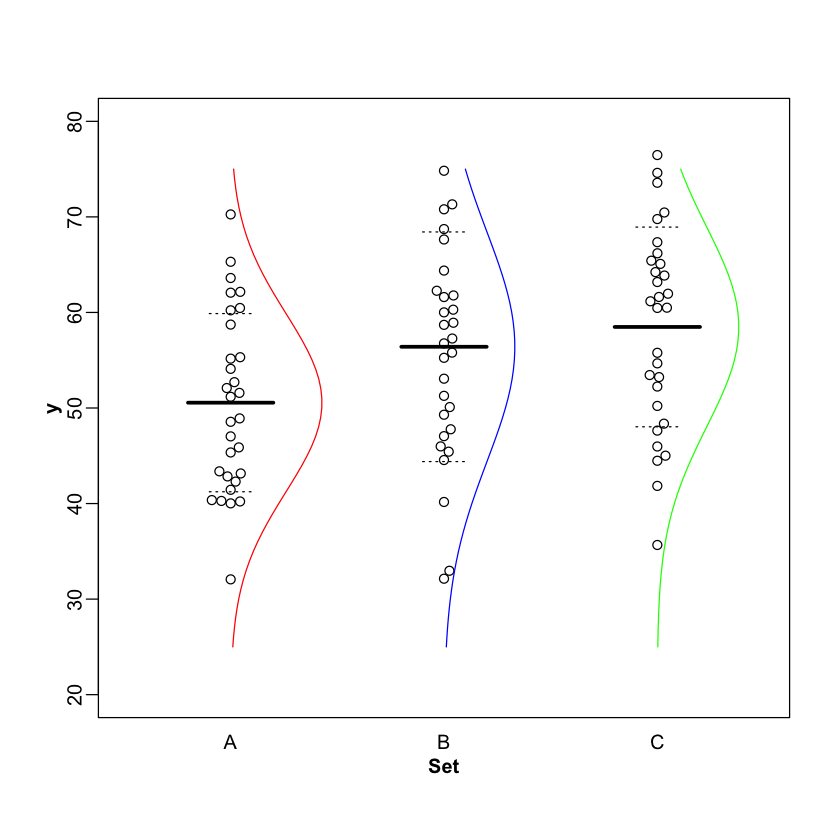

In [2]:
#A prettier way to plot — one dot per measurement, nudged sideways so none are hidden
beeplot=beeswarm( data.frame(A=randVec1,B=randVec2, C= randVec3),ylim=c(20,80),
                  xlab="Set",ylab="y",mgp = c(1.5, 0.5, 0) ,  font.lab=2 )

#plotting means — a thick line through each group
segments(0.8,mean(randVec1),1.2,mean(randVec1),lwd=3)
segments(1.8,mean(randVec2),2.2,mean(randVec2),lwd=3)
segments(2.8,mean(randVec3),3.2,mean(randVec3),lwd=3)

#standard deviations — dotted lines one SD above and below each mean.
#The spread between the thick lines is the signal; the height of the dotted bands is the noise.
segments(0.9,mean(randVec1)+sd(randVec1),1.1,mean(randVec1)+sd(randVec1),lwd=1,lty="dotted")
segments(0.9,mean(randVec1)-sd(randVec1),1.1,mean(randVec1)-sd(randVec1),lwd=1,lty="dotted")
segments(1.9,mean(randVec2)+sd(randVec2),2.1,mean(randVec2)+sd(randVec2),lwd=1,lty="dotted")
segments(1.9,mean(randVec2)-sd(randVec2),2.1,mean(randVec2)-sd(randVec2),lwd=1,lty="dotted")
segments(2.9,mean(randVec3)+sd(randVec3),3.1,mean(randVec3)+sd(randVec3),lwd=1,lty="dotted")
segments(2.9,mean(randVec3)-sd(randVec3),3.1,mean(randVec3)-sd(randVec3),lwd=1,lty="dotted")



#calculating the probability curves — the height of each group's bell curve from 25 to 75
probCurve1=dnorm(25:75, mean(randVec1), sd = sd(randVec1))
probCurve2=dnorm(25:75, mean(randVec2), sd = sd(randVec2))
probCurve3=dnorm(25:75, mean(randVec3), sd = sd(randVec3))

#probability distributions — drawn sideways beside each group.
#"1+", "2+", "3+" place each curve at its group; "10*" just makes it wide enough to see.
lines(y=25:75, x=1+10*probCurve1, col="red")
lines(y=25:75, x=2+10*probCurve2, col="blue")
lines(y=25:75, x=3+10*probCurve3, col="green")


Next, we run the analysis code.

In R, you run first the model, then calculate the ANOVA table and lastly, the Tukey.

The most interesting part is the "Pr(>F)" part, this is the p-value for the overall ANOVA. The
remaining values are less important.

If you want to know what the other columns are: `Df` is the degrees of freedom, `Sum Sq` and
`Mean Sq` measure the variation between groups (top row) against the variation left over inside
them (bottom row), and `F value` is the ratio of those two. A large F means the groups are further
apart than the scatter within them would explain.

In [3]:
#ANOVA
#First the model
#y is a function of x  — read "~" as "explained by": the measurement is explained by which group it came from
AOV=aov(y~x, data = DF)

#Then the ANOVA table
anova(AOV)


,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
x,2,1013.580,506.7900,4.465059,0.01425758
Residuals,87,9874.612,113.5013,NA,NA


Finally, we calculate the Tukey test.

Each row is one pair of groups. `diff` is the difference between their means, `lwr` and `upr` are
the ends of a 95% confidence interval for that difference, and `p adj` is the p-value — adjusted for
the fact that we are looking at three comparisons at once. **If the interval crosses zero, the
difference is not significant.**

In [4]:
# Tukey's Honest Significant Difference: every pair of groups, with the p-values
# already adjusted for the fact that we are making three comparisons instead of one.
TukeyHSD(AOV)

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = y ~ x, data = DF)

$x
        diff        lwr       upr     p adj
B-A 5.851458 -0.7077042 12.410620 0.0902432
C-A 7.925661  1.3664992 14.484824 0.0136885
C-B 2.074203 -4.4849590  8.633366 0.7320002


**Question 2.1**
What is the interpretation of the p-value from the ANOVA. Do we now know which groups are different or is the just the overall model?

**Question 2.2**
Inspect the output of the tukey test. Which groups are different? And what is ment by the 'adj' in the output?

**Question 2.3** Change the parameters above until C is different from both A and B.

# Linear regression
We use linear regression when analyzing the association between two numeric variables.

Just as the ANOVA, this uses the concept of a **model** and has to be carefully formulated with the '~' notation.

> **Terms**
>
> - **Slope** — how much the outcome moves per one-unit rise in the predictor. This is usually the
>   number you care about.
> - **Intercept** — what the model predicts when the predictor is zero. Sometimes meaningful,
>   often not (there may be no such thing as a patient of age zero).
> - **R²** — the fraction of the variation in the outcome that the line accounts for, between 0 and 1.
> - **R² and the p-value answer different questions.** The p-value asks whether there is *any*
>   association; R² asks how *much* of the variation it explains. With enough data you can have a
>   tiny R² and a very small p-value at the same time — a real association that predicts almost
>   nothing.

We here generate two random data sets with two different slopes and plot them

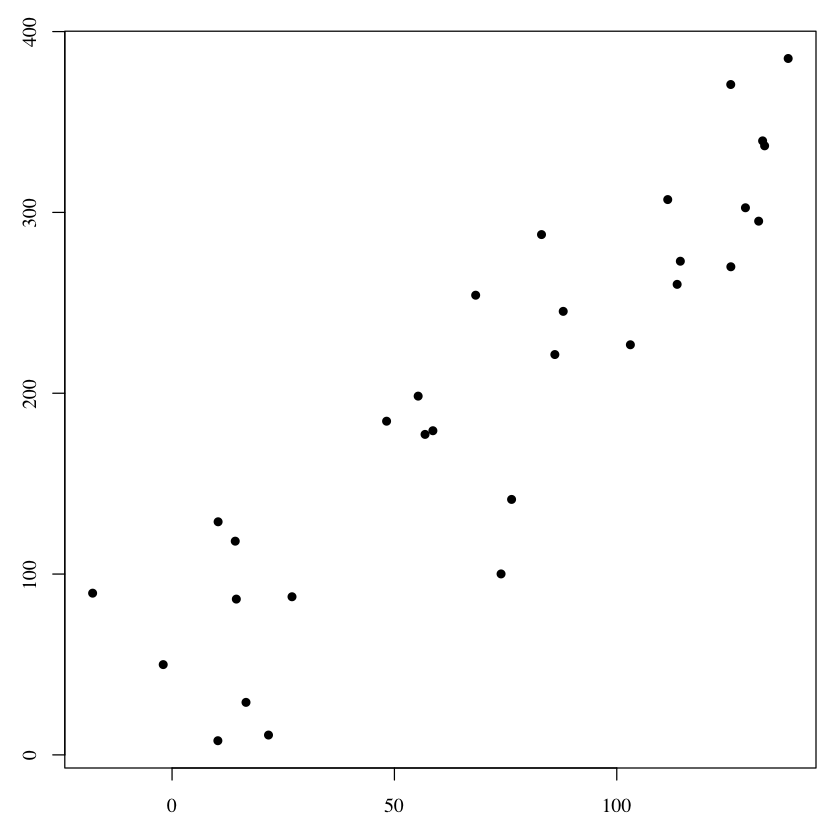

In [5]:
rm(list = ls())

#plotting stuff
par(mfrow=c(1,1))
par(mar = c(3.,2.7,1.3,1))
par(family="serif")

#parameters — two variables, each rising with a different slope, plus random noise
n1=30
slope1=5
offset1=2
noise1=20

n2=30
slope2=12
offset2=10
noise2=20

#two random data sets
#seq(1:n) counts 1,2,3,...,n; multiply by the slope, add the offset, then add noise
randVec1=seq(1:n1)*slope1 + offset1 + rnorm(n1,0,noise1)
randVec2=seq(1:n2)*slope2 + offset2 + rnorm(n2,0,noise2)

#plot — each point is one observation: its randVec1 value against its randVec2 value
plot(randVec2 ~ randVec1, pch=16)


Next we run the regression model with the lm() function (Linear Model) and extract the coefficients with summary().

The important part in linear regression is the "Estimates", corresponding to the coefficients in linear regression.

In [6]:
#run regression
#same "~" notation as the ANOVA: randVec2 is explained by randVec1
LM=lm(randVec2 ~ randVec1)

#extract coefficients
#read the Estimate column: (Intercept) is the value when randVec1 = 0,
#and the randVec1 row is how much randVec2 changes per 1-unit rise in randVec1
summary(LM)



Call:
lm(formula = randVec2 ~ randVec1)

Residuals:
     Min       1Q   Median       3Q      Max 
-103.582  -26.788    5.929   33.567   74.405 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  51.7093    15.6633   3.301  0.00263 ** 
randVec1      2.0539     0.1822  11.272 6.43e-12 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 47.44 on 28 degrees of freedom
Multiple R-squared:  0.8194,	Adjusted R-squared:  0.813 
F-statistic: 127.1 on 1 and 28 DF,  p-value: 6.429e-12


Then we plot the results and regression line on the figure.

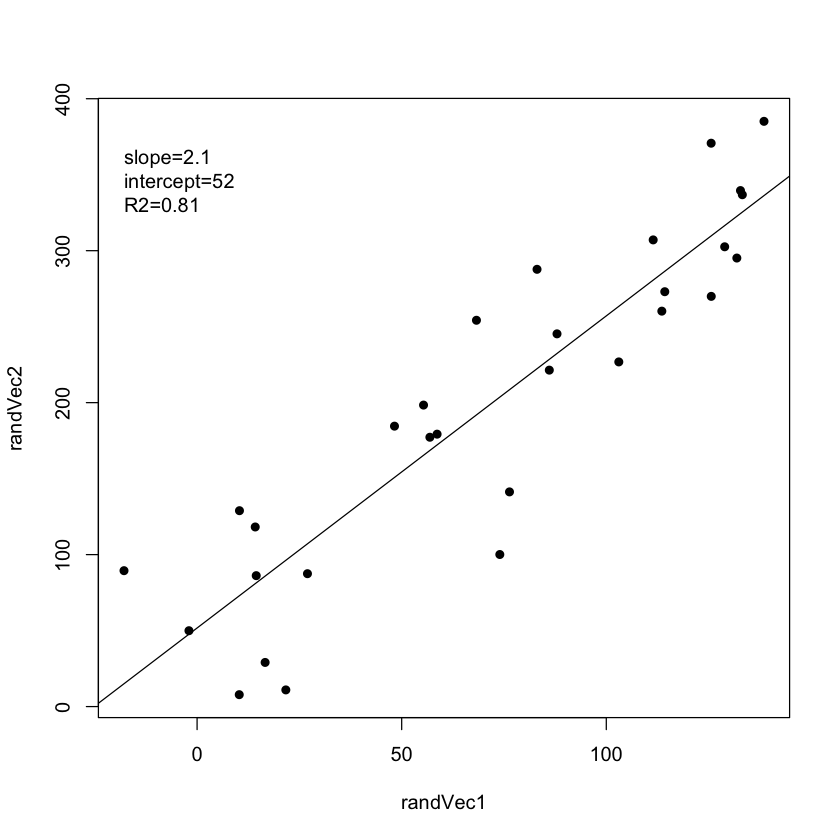

In [7]:
#plot
plot(randVec2 ~ randVec1, pch=16)
#plot line — abline() draws the fitted straight line straight from the model
abline(LM)
#add slope — signif() rounds to 2 significant digits so the label stays readable
text(x = min(randVec1),max(randVec2)*0.9, paste("slope=",signif(LM$coefficients[2],2),"\n",
                                 "intercept=",signif(LM$coefficients[1],2),"\n",
                                 "R2=", signif(summary(LM)$adj.r.squared,2),
                                 sep=""),adj=0,
       )

**Question 2.4** What is the interpretation of the Estimates? What is the value of randVec2 when randVec1=0? What happens to randVec2 when randVec1 increases by 1?

**Question 2.5** Is this a strong association given the R2 value?




**Question 2.6** The ANOVA and the regression both used the `~` notation, and both are the same
kind of model underneath — a *linear model*. What is the difference between the two situations? Look
at what sits on the right of the `~` in each case.

**Question 2.7** Increase `noise1` and `noise2` to 100 and rerun the regression. What happens to the
slope estimate, and what happens to R²? Which of the two is telling you that the data got worse?